# Problem Statement:
## Use Euler's Method to solve the differential equation  
$$\frac{dx}{dt} = -x^3 + \sin(t)$$  
with initial condition $x = 0$ at $t = 0$.

*Source: Mark Newman, Computational Physics (1st Edition)*

# We will demonstrate 4 versions of Euler's Method:
* Version 1. Author **Newman's original** version as covered in his textbook.
* Version 2. A **modern version** using updated syntax.
* Version 3. Uses **vectorization** and **batch computing** for efficient processing.
* Version 4. Fast Euler solver using **Numba**.

# Version 1. Baseline Implementation (Newman, 2013)
Source: Mark Newman, *Computational Physics (1st Edition)*, https://websites.umich.edu/~mejn/cp2/programs/euler.py

The code in the following cell is taken directly from Newman's website linked above.

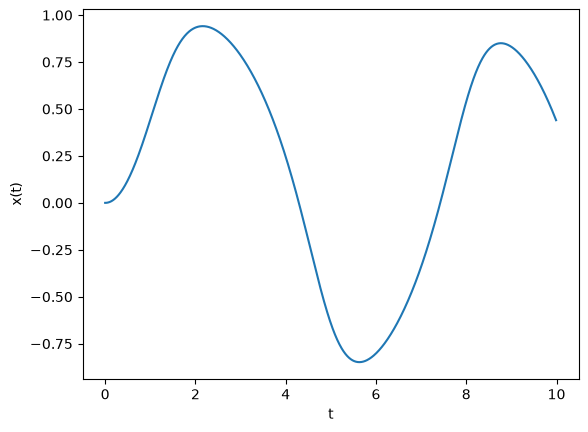

In [1]:
from math import sin
from numpy import arange
import matplotlib.pyplot as plt

def f(x,t):
    return -x**3 + sin(t)

a = 0.0           # Start of the interval
b = 10.0          # End of the interval
N = 1000          # Number of steps
h = (b-a)/N       # Size of a single step
x = 0.0           # Initial condition

tpoints = arange(a,b,h)
xpoints = []
for t in tpoints:
    xpoints.append(x)
    x += h*f(x,t)

plt.plot(tpoints,xpoints)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.show()

# Version 2. Euler's Method using modernized syntax.
### Improvements
1. Used **`np.linspace` instead of `np.arange`** to prevent off-by-one errors in the $t$-axis caused by  floating-point step drift. This guarantees an exact array size `n_steps`. 
2. Used **Matplotlib object-oriented API (`fig`, `ax`)** instead of the stateful `pyplot` interface. Explicit `Figure` and `Axes` instances offer better control, readability, and scalability when handling complex or multi-panel plots.
3. Used explicit **type hints** to clarify the expected data types of function arguments and return values.
4. **Pre-allocated memory** with `np.empty` to improve performance. The old way initialized an empty array `x_points = []` and appended to it inside a 1,000-step loop.
5. **Encapsulation and reusability** improvements: put the solver inside a function and prevented Matplotlib from drawing plots if the code were imported into another program.

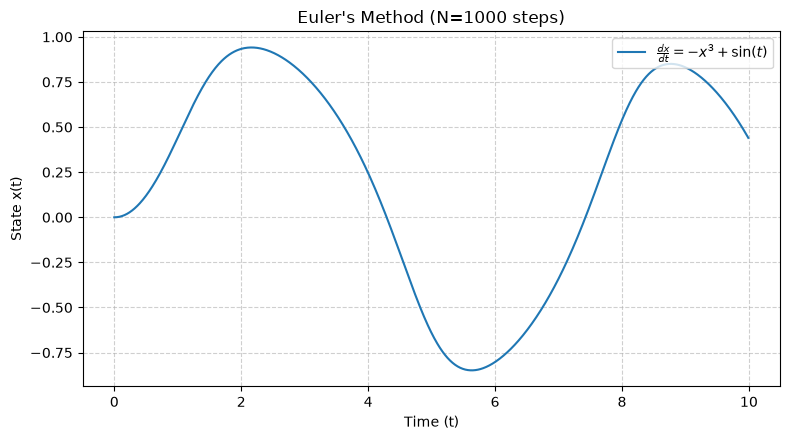

In [2]:
# Version 2: Euler's Method using modernized syntax.

from typing import Tuple
import matplotlib.pyplot as plt
import numpy as np
import math


def solve_euler_modern(
    t_start: float = 0.0,
    t_end: float = 10.0,
    n_steps: int = 1000,
    x0: float = 0.0,
) -> Tuple[np.ndarray, np.ndarray]:
    """Uses Euler's method to solve ODE dx/dt = f(x, t) where f(x, t) is defined in the function above.
    Returns Tuple[time points array, solved values x(t) array].
    """

    # Use linspace to prevent off-by-one errors caused by floating-point step drift
    # Because of the retstep=True flag, we get
    # t_points: array of time points. h: exact calculated step size (scalar) between points
    t_points, h = np.linspace(t_start, t_end, n_steps, retstep=True, endpoint=False)

    # Pre-allocate memory to avoid list append overhead
    x_points = np.empty(n_steps, dtype=np.float64)
    
    x = x0
    for i in range(n_steps):
        x_points[i] = x

        # This is gonna make 3 temp arrays per iteration, but let's compare with V3's in-place ufuncs
        x += h * (-(x**3) + math.sin(t_points[i]))
        
    return t_points, x_points


if __name__ == "__main__":
    t_points, x_points = solve_euler_modern()
    
    # Modern object-oriented Matplotlib API
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(t_points, x_points, label=r"$\frac{dx}{dt} = -x^3 + \sin(t)$", color="tab:blue")
    ax.set_title(f"Euler's Method (N={len(t_points)} steps)")
    ax.set_xlabel("Time (t)")
    ax.set_ylabel("State x(t)")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

# Version 3. Vectorization and batch computing.

We cannot avoid a `for` loop, because each step of Euler Method depends on the previous step:
$$x_{k+1} = x_k + h*f(x_k, t_k)$$

Even though iteration is necessary, we can vectorize aspects of our computation and take advantage of SIMD and NumPy's C-speed capabilities:
1. Vectorize the term $\sin(t)$ in advance for all $t$.
2. If we happen to have multiple initial conditions $x_0$ (`x0_batch` array), we can apply the Euler Method to all trajectories in parallel.



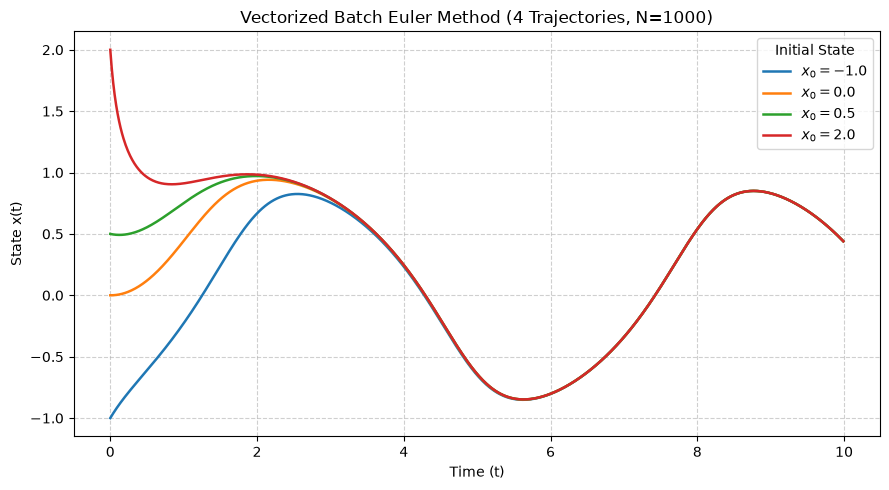

In [3]:
# Version 3. Vectorization and batch computing.

from typing import Tuple
import matplotlib.pyplot as plt
import numpy as np


def solve_euler_vectorized_batch(
    t_start: float = 0.0,
    t_end: float = 10.0,
    n_steps: int = 1000,
    x0_batch: np.ndarray | None = None,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Optimized Euler's method that uses vector pre-computation and allows for batch trajectory
    calculation across multiple initial conditions. The array of multiple initial conditions 
    is assumed to be supplied by the user.
    
    This version uses vector pre-computation for the sin(t) term in function 
    f(x, t) = -x^3 + sin(t).
    
    Returns Tuple[time points array, 2D array for all trajectories x(t)].
    """

    if x0_batch is None:
        x0_batch = np.array([0.0, 0.5, 1.0, 1.5])
    
    # Because of the retstep=True flag, we get
    # t_points: array of time points. h: exact calculated step size (scalar) between points
    t_points, h = np.linspace(t_start, t_end, n_steps, retstep=True, endpoint=False)

    sin_t = np.sin(t_points)  # vectorized for C-speed

    # Pre-allocate 2D grid for multiple trajectories
    num_trajectories = len(x0_batch)
    x_grid = np.empty((n_steps, num_trajectories), dtype=np.float64)

    # Prepare an independent copy of x0_batch array w/ 64bit precision
    x = x0_batch.astype(np.float64).copy()
    
    # A reusable buffer to avoid temp array allocations in the for loop below
    dxdt = np.empty_like(x)
    
    # Euler iteration vectorized across all trajectories
    for i in range(n_steps):
        x_grid[i] = x

        # The Euler calculation we want to do:
        # x += h * (-(x**3) + sin_t[i])

        # We will do the above in-place to prevent allocating new memory
        np.power(x, 3, out=dxdt)      # dxdt = x^3
        np.negative(dxdt, out=dxdt)   # dxdt = -x^3
        dxdt += sin_t[i]              # dxdt = -x^3 + sin_t[i]
        dxdt *= h                     # dxdt = h * (-x^3 + sin_t[i])

        x += dxdt                     # Update x in-place

    return t_points, x_grid


if __name__ == "__main__":

    init_conds = np.array([-1.0, 0.0, 0.5, 2.0]) #user-defined initial conditions
    t_points, x_grid = solve_euler_vectorized_batch(x0_batch=init_conds)
    fig, ax = plt.subplots(figsize=(9, 5))

    # x_grid has shape (n_steps, num_trajectories)
    # We loop over each trajectory to give each its own color, label and legend entry.
    for i, x0 in enumerate(init_conds):
        ax.plot(t_points, x_grid[:, i], label=f"$x_0 = {x0}$", linewidth=1.8)

    ax.set_title(f"Vectorized Batch Euler Method ({len(init_conds)} Trajectories, N={len(t_points)})")
    ax.set_xlabel("Time (t)")
    ax.set_ylabel("State x(t)")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(title="Initial State", loc="upper right")

    plt.tight_layout()
    plt.show()


# Version 4: Numba

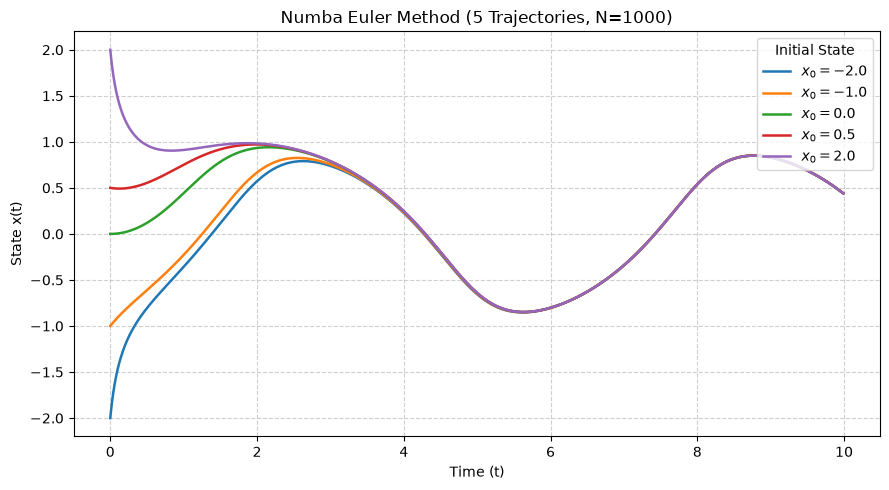

In [4]:
from typing import Tuple
import matplotlib.pyplot as plt
import math
import numpy as np
import numba

@numba.njit
def eul_numba(
    t_start: float,
    t_end: float,
    n_steps: int,
    x0_batch: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Euler's method that uses JIT compilation via Numba. Allows for batch trajectory
    calculation across multiple initial conditions. The array of multiple initial conditions 
    is assumed to be supplied by the user.
    
    We're assuming an ODE with function f(x, t) = -x^3 + sin(t).
    
    Returns Tuple[time points array, 2D array for all trajectories x(t)].
    """

    # Calculate step size manually because Numba doesn't support retstep=True in np.linspace.
    # Numba also doesn't like endpoint=False
    h = (t_end - t_start) / n_steps
    t_points = np.linspace(t_start, t_end - h, n_steps)

    # Pre-allocate 2D grid for multiple trajectories
    num_trajectories = len(x0_batch)
    x_grid = np.empty((n_steps, num_trajectories), dtype=np.float64)

    # The .astype(np.float64) of Version 3 isn't supported by Numba. Just ensure x0_batch
    # is passed in with dtype=np.float64
    x = x0_batch.copy()

    for i in range(n_steps):
        x_grid[i] = x
        for j in range(num_trajectories):
            x[j] += h * (-(x[j] ** 3) + math.sin(t_points[i]))

    return t_points, x_grid

# Python wrapper to handle default arguments before handing off to JIT
# Numba can't handle x0_batch: np.ndarray | None = None
def solve_euler_numba(
    t_start: float = 0.0,
    t_end: float = 10.0,
    n_steps: int = 1000,
    x0_batch: np.ndarray | None = None,
) -> Tuple[np.ndarray, np.ndarray]:

    if x0_batch is None:
        x0_batch = np.array([0.0, 0.5, 1.0, 1.5], dtype=np.float64)
    else:
        x0_batch = np.asarray(x0_batch, dtype=np.float64)

    return eul_numba(t_start, t_end, n_steps, x0_batch)
        
if __name__ == "__main__":

    plot4_init = np.array([-2.0, -1.0, 0.0, 0.5, 2.0]) #user-defined initial conditions
    t_pts_plot4, x_grid_plot4 = solve_euler_numba(x0_batch=plot4_init)
    fig4, ax4 = plt.subplots(figsize=(9, 5))

    # x_grid has shape (n_steps, num_trajectories)
    # We loop over each trajectory to give each its own color, label and legend entry.
    for i, x0 in enumerate(plot4_init):
        ax4.plot(t_pts_plot4, x_grid_plot4[:, i], label=f"$x_0 = {x0}$", linewidth=1.8)

    ax4.set_title(f"Numba Euler Method ({len(plot4_init)} Trajectories, N={len(t_pts_plot4)})")
    ax4.set_xlabel("Time (t)")
    ax4.set_ylabel("State x(t)")
    ax4.grid(True, linestyle="--", alpha=0.6)
    ax4.legend(title="Initial State", loc="upper right")

    plt.tight_layout()
    plt.show()

# Comparing the times to execute the different Versions.

In [5]:
import timeit
from math import sin
from numpy import arange
import numpy as np

# Define a wrapper for Newman's V1 script to benchmark it cleanly
def solve_euler_v1_newman(a=0.0, b=10.0, N=1000, x0=0.0):
    """Wrapper function executing Version 1, Newman's baseline code"""
    def f_v1(x, t):
        return -x**3 + sin(t)

    h = (b - a) / N
    x = x0
    tpoints = arange(a, b, h)
    xpoints = []
    for t in tpoints:
        xpoints.append(x)
        x += h * f_v1(x, t)
    return tpoints, xpoints

a, b, N, x0 = 0.0, 10.0, 1000, 0.0  # standardized parameters
x0_batch = np.array([-1.0, 0.0, 0.5, 2.0])  # multiple trajectory trial
x0_large_batch = np.linspace(-1.0, 2.0, 100)  # many trajectories

print(f"Benchmarking Euler Solvers (N={N} steps)\n")

# Version 1. Newman Baseline, 1 trajectory
t_v1 = %timeit -o -q solve_euler_v1_newman(a, b, N, x0)
print(f"Version 1 (Newman Baseline, 1 trajectory): {t_v1.average * 1e3:.3f} ms")

# Version 2. Modern Scalar, 1 trajectory
t_v2 = %timeit -o -q solve_euler_modern(a, b, N, x0)
print(f"\nVersion 2 (Modern Scalar, 1 trajectory): {t_v2.average * 1e3:.3f} ms")

# ------- VERSION 3, 4 TRAJECTORIES ---------
# Version 3. Vectorized Batch, 4 trajectories
t_v3 = %timeit -o -q solve_euler_vectorized_batch(a, b, N, x0_batch)
print(f"\nVersion 3 (Vectorized Batch, {len(x0_batch)} trajectories): {t_v3.average * 1e3:.3f} ms")

# Calculate amortized cost per trajectory for Version 3
v3_per_traj = (t_v3.average / len(x0_batch)) * 1e3
print(f"V3 Amortized time: {v3_per_traj:.3f} ms per trajectory")

# ------- VERSION 3, MANY TRAJECTORIES --------
t_v3_large = %timeit -o -q solve_euler_vectorized_batch(a, b, N, x0_large_batch)
print(f"\nVersion 3 (Vectorized Batch, {len(x0_large_batch)} trajectories): {t_v3_large.average * 1e3:.3f} ms")

# Calculate amortized cost per trajectory for large batch Version 3
v3_large_per_traj = (t_v3_large.average / len(x0_large_batch)) * 1e3
print(f"V3 Large Batch Amortized time: {v3_large_per_traj:.3f} ms per trajectory")

# ------- VERSION 4, NUMBA ------------
# Force JIT compilation warm-up before timing
_t, _x = solve_euler_numba(a, b, N, x0_batch)

t_v4 = %timeit -o -q solve_euler_numba(a, b, N, x0_batch)
print(f"\nVersion 4 (Numba Euler Batch, {len(x0_batch)} trajectories): {t_v4.average * 1e3:.3f} ms")

# Calculate amortized cost per trajectory for large batch Version 4
v4_per_traj = (t_v4.average / len(x0_batch)) * 1e3
print(f"V4 Numba Amortized time: {v4_per_traj:.3f} ms per trajectory")


Benchmarking Euler Solvers (N=1000 steps)

Version 1 (Newman Baseline, 1 trajectory): 0.862 ms

Version 2 (Modern Scalar, 1 trajectory): 1.455 ms

Version 3 (Vectorized Batch, 4 trajectories): 12.818 ms
V3 Amortized time: 3.204 ms per trajectory

Version 3 (Vectorized Batch, 100 trajectories): 18.246 ms
V3 Large Batch Amortized time: 0.182 ms per trajectory

Version 4 (Numba Euler Batch, 4 trajectories): 0.042 ms
V4 Numba Amortized time: 0.010 ms per trajectory


# Added Version 4, an Euler solver that uses Numba.
Here, we are calculating 4 trajectories, and even that is more than 20 times faster than the Newman Baseline Euler solver!

# NumPy's Strength: Simultaneously calculating many trajectories
* We compared Version 3 run with 4 trajectories vs. 100 trajectories. While the total ms of the 100-trajectory run was ~3x the time of the 4-trajectory run, the amortized time per trajectory was a lot less, especially considering the large increase in the number of trajectories!
* Per trajectory, calculating 100 trajectories simultaneously with Version 3 is twice as fast as running 1 trajectory with the baseline Version 1 (0.183 vs 0.363 ms/traj).


# Why V2 (Modernized Syntax) does worse than V1 (Newman's Original)
We are getting benchmarking results such as:  
Version 1 (Newman Baseline, 1 trajectory): 0.366 ms  
Version 2 (Modern Scalar, 1 trajectory): 0.626 ms  

I think V2 is slower because of a tax introduced by indexing a NumPy array inside a Python loop.

## Indexing by position `[i]` vs direct array iterator
V2 indexes by position (`t_points[i]`), while V1 iterates `for t in tpoints` directly. Indexing by position carries extra CPython method lookup tax compared to a direct array iterator.

## V2 incurs overhead when assigning `x_points[i] = x`
* In V2, the Python float `x` needs to be cast before written to NumPy array `x_points[i]`.
* In V1, `xpoints.append(x)` appends a pure Python scalar to a standard Python list, which is fast.

# Why V3 does worse than the others for small batches:
This may be a NumPy ufunc overhead issue. We have 5 NumPy ufuncs in our 1000-step loop: `np.power`, `np.negative`, `*=`, `+=`. Each ufunc call carries CPython API and type-checking overhead.